# PERTURBATION ANALYSIS

# Setup

In [1]:
from src.system_discovery import SystemDiscovery, discoverNetwork
import src.constants as cn
from src.biomodels_iterator import BiomodelsIterator
from src.timecourse import Timecourse
from src.model import Model
from src.score import Score

import os
import numpy as np  # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
from typing import Optional

# Single System Analyssis

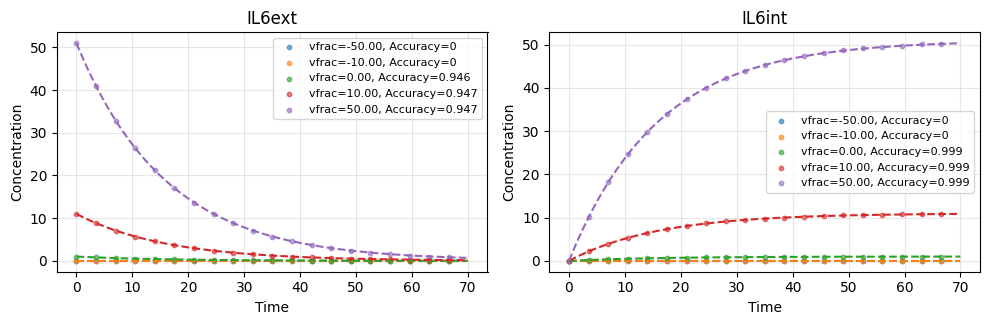

In [2]:
analyze_df = SystemDiscovery.analyzePerturbations(1004, perturbations=[-50, -10, 0, 10, 50], frac_scatter_skip=0.05,
        subtitle="", plot_species_names=["IL6ext","IL6int"])

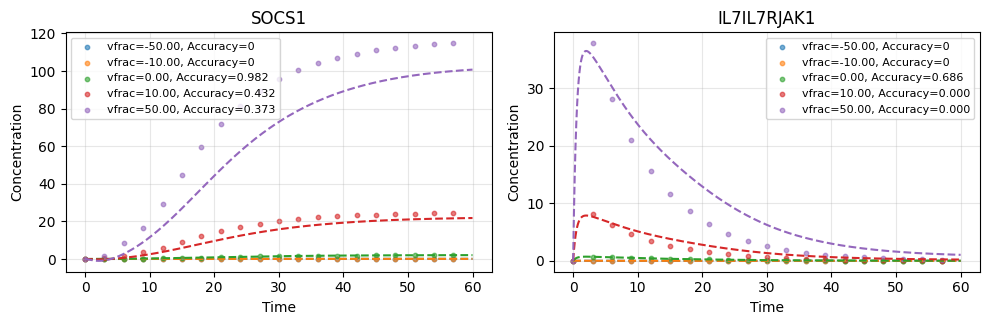

In [3]:
analyze_df = SystemDiscovery.analyzePerturbations(968, perturbations=[-50, -10, 0, 10, 50], frac_scatter_skip=0.05,
   plot_species_names=["SOCS1", "IL7IL7RJAK1"],
#    plot_species_names=["STAT5", "pSTAT5", "SOCS1", "IL7IL7RJAK1"]
subtitle="")

# CDFs

In [6]:
PATH = os.path.join(cn.DATA_DIR, "perturbation_study-species0.001.csv")
#PATH = os.path.join(cn.DATA_DIR, "linear_predictor_scores_1" + ".csv")
df = pd.read_csv(PATH)
DF_DCT = {p: df[p] for p in ['min', 'p10', 'p50']}
[(p, len(d)) for p, d in DF_DCT.items()]

[('min', 35181), ('p10', 35181), ('p50', 35181)]

Create a DF where the columns are min, p10, p50, perturb-0, perturb-10, perturb-50

In [ ]:
def plotPerturbation(col: str):
    dff = DF_P_DCT[col]
    dff["aggregation_type"] = "model"
    score = Score.deserialize()
    score.score_df = dff
    score.plotCDF([-0.5, -0.1, 0, 0.10, 0.50], title="CDF: " + col)

In [ ]:
for col in ["min", "p10", "p50"]:
    plotPerturbation(col)
    plt.figure()

In [ ]:
df.pivot(columns='perturbation', values='p10', index='system_id')


This differs a bit from the analysis without perturbations since models are eliminated if their state cannot be manipulated (e.g., arithmetic rules)